# 📦 UN Comtrade 무역 데이터로 풀어보는 3가지 질문

> **실습 방식**
> 단순 함수 연습이 아니라 **'질문 → 가설 → 탐색 → 시각화 → 인사이트'** 의 EDA 흐름을 따라갑니다.
> 한 주제당 5~7개의 문제로 데이터를 파고듭니다.

---

### 🎯 오늘 풀어볼 3가지 질문

| # | 주제 | 핵심 질문 |
|:---:|:---|:---|
| 1 | 🇨🇳 **대중국 무역수지 역전** | 흑자에서 적자로 바뀐 건 언제? 진짜 원인은 수입 증가일까, 수출 감소일까? |
| 2 | 💾 **반도체의 두 얼굴** | HS 8542는 수출도 1위, 수입도 1위라는데 국가별 교역 구조는? |
| 3 | 🇺🇸 **교역 무게중심 이동** | 2020년과 2024년, 3개국 수출 구조는 얼마나 달라졌나? |

---

### 📋 데이터 개요

| 컬럼명 | 설명 |
|:---|:---|
| 연도 | 2020~2024 |
| 교역상대국 | China, USA, Viet Nam |
| 수출입구분 | Export / Import |
| HS코드 | 4자리 품목 코드 |
| 품목명 | 영문 품목 설명 |
| 교역금액(\$) | 수출=FOB, 수입=CIF 통합 금액 |


---
## 0. 한글 폰트 설치 (Colab 전용)

실행 후 **런타임 → 세션 다시 시작** 을 눌러주세요.

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,633 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direc

## 1. 라이브러리 불러오기 & 데이터 로드

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 데이터 다운로드
!gdown 1dX3xEJdVwjoG6XywPEFy9WoboAK6EIKp

Downloading...
From: https://drive.google.com/uc?id=1dX3xEJdVwjoG6XywPEFy9WoboAK6EIKp
To: /content/TradeData.xlsx
100% 3.43M/3.43M [00:00<00:00, 33.7MB/s]


In [ ]:
df =
df

,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
0,2020,Viet Nam,Export,9999,Commodities not specified according to kind,NaN,0.0,0.000,NaN,12293389.0,12293389,H5
1,2020,China,Export,9999,Commodities not specified according to kind,NaN,0.0,0.000,NaN,3402788.0,3402788,H5
2,2020,USA,Export,9999,Commodities not specified according to kind,NaN,0.0,0.000,NaN,166872635.0,166872635,H5
3,2020,China,Export,8601,Rail locomotives; powered from an external sou...,u,0.0,30.500,NaN,429.0,429,H5
4,2020,USA,Export,6210,Garments made up of fabrics of heading no. 560...,NaN,0.0,32964.446,NaN,1313112.0,1313112,H5
...,...,...,...,...,...,...,...,...,...,...,...,...
32090,2024,China,Import,9032,Regulating or controlling instruments and appa...,NaN,0.0,7322576.564,397176666.0,NaN,397176666,H6
32091,2024,USA,Import,2522,"Quicklime, slaked lime and hydraulic lime; oth...",NaN,0.0,NaN,27.0,NaN,27,H6
32092,2024,USA,Import,8908,Vessels and other floating structures; for bre...,NaN,0.0,NaN,879.0,NaN,879,H6
32093,2024,USA,Import,4103,Raw hides and skins n.e.c in headings no. 4101...,NaN,0.0,NaN,6405.0,NaN,6405,H6


---
## 2. 데이터 구조 빠르게 훑기

분석에 들어가기 전, **데이터가 대략 어떻게 생겼는지만** 확인합니다. (깊게 파지 않습니다)

### 🔎 2-1. 데이터 크기와 컬럼
몇 행 × 몇 열인지, 어떤 컬럼이 있는지 확인하세요.

(32095, 12)

Index(['연도', '교역상대국', '수출입구분', 'HS코드', '품목명', '수량단위', '수량', '순중량(kg)',
       'CIF금액($)', 'FOB금액($)', '교역금액($)', 'HS분류버전'],
      dtype='object')

### 🔎 2-2. 실제 데이터 맛보기
앞 5행을 출력하세요.

,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
0,2020,Viet Nam,Export,9999,Commodities not specified according to kind,NaN,0.0,0.000,NaN,12293389.0,12293389,H5
1,2020,China,Export,9999,Commodities not specified according to kind,NaN,0.0,0.000,NaN,3402788.0,3402788,H5
2,2020,USA,Export,9999,Commodities not specified according to kind,NaN,0.0,0.000,NaN,166872635.0,166872635,H5
3,2020,China,Export,8601,Rail locomotives; powered from an external sou...,u,0.0,30.500,NaN,429.0,429,H5
4,2020,USA,Export,6210,Garments made up of fabrics of heading no. 560...,NaN,0.0,32964.446,NaN,1313112.0,1313112,H5


### 🔎 2-3. 수치형 기술통계
`교역금액($)`의 분포를 기술통계로 살펴보세요.

> 💡 평균이 중앙값의 33배 정도로 큽니다. 일부 초대형 품목이 평균을 끌어올리는 **우편향 분포**입니다.

,교역금액($)
count,3.209500e+04
mean,8.351979e+07
std,7.865005e+08
min,1.000000e+00
25%,1.619780e+05
50%,2.507866e+06
75%,2.229419e+07
max,4.881209e+10


### 🔎 2-4. 고유값 확인
분석 범위를 알아둡니다 — 연도·국가·수출입구분을 차례로 확인하세요.

array([2020, 2021, 2022, 2023, 2024])

array(['Viet Nam', 'China', 'USA'], dtype=object)

array(['Export', 'Import'], dtype=object)

> 📌 **정리**: 2020~2024년 한국과 China·USA·Viet Nam 3개국 간의 수출입 데이터, 약 3.2만 건입니다.
> 이제 본격적인 3가지 주제를 탐색하러 갑시다.

---
---
# 🇨🇳 주제 1. 대중국 무역수지는 언제 적자로 돌아섰나?

> **배경 지식**
> - 한국은 오랜 기간 대중국 무역수지 흑자국이었습니다.
> - 하지만 최근 뉴스에서 "대중 적자 전환"이라는 보도가 나왔습니다.
> - 이 데이터로 **그 전환점이 정확히 언제인지, 왜 그런 일이 벌어졌는지** 확인해봅시다.

### 💡 분석 가설
- 가설 A: 중국산 **수입이 늘어서** 적자가 됐다 (중국 제품 수입 확대)
- 가설 B: 한국의 **수출이 줄어서** 적자가 됐다 (중국 경기 둔화, 반도체 불황)
- 어느 쪽이 진짜일까요?

### 📌 1-1. 중국 데이터만 뽑아내기
`교역상대국`이 'China'인 행만 필터링해 `china`라는 변수에 저장하고, 행 수를 확인하세요.

In [ ]:
china =
china.shape

(11068, 12)

### 📌 1-2. 연도별 × 수출입구분별 금액 합계
중국 데이터에서 **연도와 수출입구분별로** 교역금액의 합계를 구하세요.

In [ ]:
china_yearly =
china_yearly

연도    수출입구분 
2020  Export    132565444433
      Import    108884236374
2021  Export    162912971626
      Import    138627456370
2022  Export    155789384747
      Import    154576138174
2023  Export    124655567747
      Import    142853875178
2024  Export    132902972287
      Import    139874969811
Name: 교역금액($), dtype: int64

In [ ]:
# (코드 실행) Export와 Import를 컬럼으로 펼치기
china_yearly = china_yearly.unstack()
china_yearly

수출입구분,Export,Import
연도,,
2020,132565444433,108884236374
2021,162912971626,138627456370
2022,155789384747,154576138174
2023,124655567747,142853875178
2024,132902972287,139874969811


### 📌 1-3. 무역수지 새 컬럼 추가
무역수지 = 수출(Export) − 수입(Import) 로 정의됩니다.
위 표에 `무역수지` 컬럼을 새로 만들어 추가하세요.

> 💡 양수면 흑자, 음수면 적자입니다.

In [ ]:
china_yearly['무역수지'] =
china_yearly

수출입구분,Export,Import,무역수지
연도,,,
2020,132565444433,108884236374,23681208059
2021,162912971626,138627456370,24285515256
2022,155789384747,154576138174,1213246573
2023,124655567747,142853875178,-18198307431
2024,132902972287,139874969811,-6971997524


### 📌 1-4. 추이 시각화
수출·수입·무역수지 세 가지를 **한 그래프에** 그려서 전환 시점을 찾아보세요.

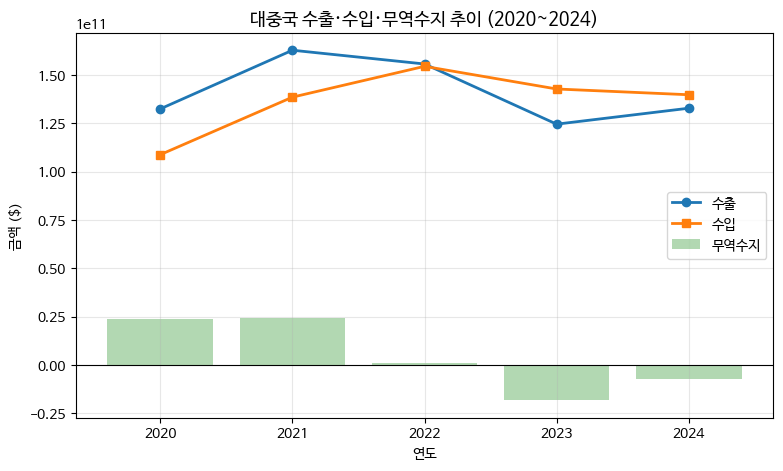

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(china_yearly.index, china_yearly['Export'], marker='o', label='수출', linewidth=2)
ax.plot(china_yearly.index, china_yearly['Import'], marker='s', label='수입', linewidth=2)
ax.bar(china_yearly.index, china_yearly['무역수지'], alpha=0.3, color='green', label='무역수지')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_title('대중국 수출·수입·무역수지 추이 (2020~2024)', fontsize=13)
ax.set_xlabel('연도')
ax.set_ylabel('금액 ($)')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

> 🔍 **1차 관찰**: 2022년까지 흑자, 2023년에 처음으로 무역수지가 **0선 아래로** 떨어집니다.
> 그런데 그래프를 자세히 보면 **수입선이 올라간 게 아니라 수출선이 꺾였습니다**. 진짜일까요? 숫자로 확인합시다.

### 📌 1-5. 2022 → 2023 변화량 계산
2023년과 2022년의 수출·수입 차이를 계산해서, **수출과 수입 중 어느 쪽이 더 크게 변했는지** 확인하세요.

In [ ]:
# (코드 실행)
change = china_yearly.loc[2023] - china_yearly.loc[2022]
change

,0
수출입구분,
Export,-31133817000
Import,-11722262996
무역수지,-19411554004


> 🔍 **결정적 증거**:
> - 수출 변화: **약 −311억 달러**
> - 수입 변화: 약 −117억 달러 (중국 수입도 사실 줄었음)
> → **가설 B가 정답**. 중국산 수입이 늘어서가 아니라, **우리 수출이 그보다 훨씬 크게 줄어서** 적자가 된 것.

그럼 어떤 품목의 수출이 이렇게 줄었을까요?

### 📌 1-6. HS 2자리 대분류 컬럼 만들기
HS코드는 4자리지만, 앞 2자리(HS2)는 **품목 대분류**를 의미합니다.
`china`에 `HS2`라는 컬럼을 새로 만드세요. (예: 8542 → '85')

> 💡 `.astype(str).str.zfill(4).str[:2]`
> `zfill(4)`는 숫자 앞을 0으로 채워 4자리로 맞추는 함수입니다 (HS 1~9로 시작하는 품목 대응).

In [ ]:
china['HS코드'] = china['HS코드'].astype(str).str.zfill(4)
china['HS2'] =
china[['HS코드', 'HS2']].head()

/tmp/ipykernel_2183/2146433660.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  china['HS코드'] = china['HS코드'].astype(str).str.zfill(4)
/tmp/ipykernel_2183/2146433660.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  china['HS2'] = china['HS코드'].str[:2]


,HS코드,HS2
1,9999,99
3,8601,86
6,7007,70
8,2804,28
9,8423,84


### 📌 1-7. 대중국 수출이 가장 많이 줄어든 품목군은?
2022년과 2023년의 **대중국 수출액**을 HS2별로 구해 비교하고, 감소폭이 큰 상위 5개를 찾으세요.

> 💡 단계: 연도별 수출 필터 → groupby로 HS2별 합계 → 뺄셈 → 정렬

In [ ]:
# 2022년 수출 데이터 선택
exp_2022 =
exp_2022.head()

,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전,HS2
12763,2022,China,Export,9999,Commodities not specified according to kind,NaN,0.0,0.000,NaN,5612207.0,5612207,H6,99
12768,2022,China,Export,9014,Navigational instruments and appliances; direc...,NaN,0.0,720.540,NaN,2235741.0,2235741,H6,90
12769,2022,China,Export,2804,"Hydrogen, rare gases and other non-metals",NaN,0.0,1856530.854,NaN,212295352.0,212295352,H6,28
12770,2022,China,Export,7321,"Stoves, ranges, grates, cookers (those with su...",NaN,0.0,125277.809,NaN,2270490.0,2270490,H6,73
12771,2022,China,Export,9403,"Furniture and parts thereof, n.e.c. in chapter 94",NaN,0.0,1224487.527,NaN,10592732.0,10592732,H6,94


In [ ]:
# 2023년 수출 데이터 선택
exp_2023 =
exp_2023.head()

,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전,HS2
19183,2023,China,Export,9999,Commodities not specified according to kind,NaN,0.0,0.000,NaN,4008742.0,4008742,H6,99
19184,2023,China,Export,0101,"Horses, asses, mules and hinnies; live",u,0.0,0.110,NaN,1.0,1,H6,01
19187,2023,China,Export,2804,"Hydrogen, rare gases and other non-metals",NaN,0.0,1594649.890,NaN,126867281.0,126867281,H6,28
19188,2023,China,Export,6211,"Track suits, swimwear and other garments (not ...",NaN,0.0,783852.878,NaN,18924530.0,18924530,H6,62
19197,2023,China,Export,8516,"Electric water, space, soil heaters; electro-t...",NaN,0.0,4051946.817,NaN,105906275.0,105906275,H6,85


In [ ]:
# exp_2022 데이터의 HS 2단위 별 교역금액 합
exp_2022 =
exp_2022

,교역금액($)
HS2,
01,76375
02,3878
03,711118747
04,12080381
05,3149059
...,...
94,256051436
95,73981448
96,44472434


In [ ]:
# exp_2023 데이터의 HS 2단위 별 교역금액 합
exp_2023 =
exp_2023

,교역금액($)
HS2,
01,29149
02,1171
03,460691768
04,13057164
05,7934758
...,...
94,233170056
95,58513491
96,38959089


In [ ]:
# (코드 실행)
drop = (exp_2023 - exp_2022).sort_values().head(5)
drop

,교역금액($)
HS2,
85,-1.939025e+10
39,-2.406209e+09
29,-1.992990e+09
90,-1.780051e+09
84,-1.212590e+09


### 📌 1-8. 시각화로 마무리
위 결과를 **수평 막대그래프**로 그려서 "누가 적자를 만들었는지" 보여주세요.

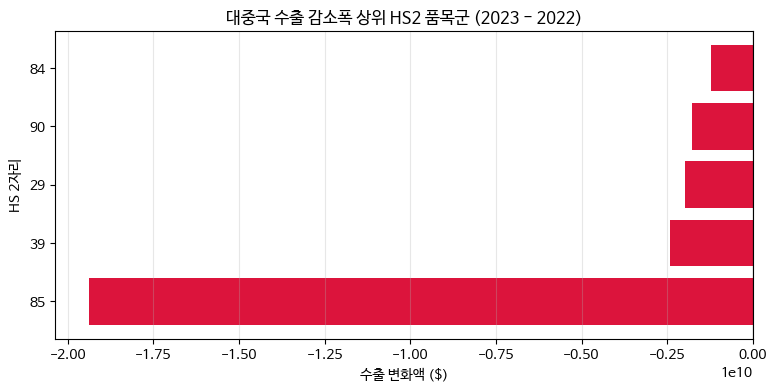

In [ ]:
plt.figure(figsize=(9, 4))
colors = ['crimson' if v < 0 else 'steelblue' for v in drop.values]
plt.barh(drop.index, drop.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('대중국 수출 감소폭 상위 HS2 품목군 (2023 - 2022)')
plt.xlabel('수출 변화액 ($)')
plt.ylabel('HS 2자리')
plt.grid(alpha=0.3, axis='x')
plt.show()

### 🎯 주제 1 결론

| 발견 | 값 |
|---|---|
| 대중국 무역수지 적자 전환 시점 | **2023년** |
| 진짜 원인 | 수입 증가 ❌ / **수출 급감 ✅** |
| 가장 많이 줄어든 수출 품목군 | **HS 85 (전기기기)** → 약 −194억 달러 |
| 해석 | HS 85의 대표 품목은 **반도체**. 2022~23년 반도체 불황·중국 수요 둔화가 직격탄 |

> 단순히 "적자 났다"가 아니라 **"왜 적자가 됐는지"** 까지 파고드는 것이 EDA의 힘입니다.

---
---
# 💾 주제 2. 반도체(HS 8542)는 수출 1위이자 수입 1위?

> **배경 지식**
> - HS 8542 = "Electronic integrated circuits" (전자 집적회로 = 반도체)
> - 앞서 본 대로 반도체 수출 부진은 무역수지에 직격탄을 주는 품목입니다.
> - 그런데 반도체는 **수출 1위면서 동시에 수입 1위**라는 독특한 품목이기도 합니다.
> - **국가별로 어떤 구조**인지 쪼개봅시다.

### 💡 분석 가설
반도체는 국가별 분업 구조가 있을 것이다.
- 한국이 중국·베트남으로는 수출, 미국으로부터는 수입이 많을 것.
- (중국·베트남=제조 기지, 미국=설계·장비 강국)

### 📌 2-1. 반도체 품목 찾기 (문자열 검색)
먼저 `품목명`에 'integrated circuit'이 들어간 행을 모두 찾아 `candidates`로 저장하세요.

> 💡 옵션: `case=False`(대소문자 무관)

In [ ]:
candidates =
candidates.shape

(60, 12)

### 📌 2-2. 어떤 HS코드가 걸렸는지 확인
검색 결과에 포함된 고유 HS코드를 확인하세요.

array([8486, 8542])

> 🤔 HS **8542** 하나만 나올 줄 알았는데 **8486**도 함께 잡혔습니다.
> 둘이 뭐가 다른지 품목명을 직접 확인해 봐야겠습니다.

### 📌 2-3. 두 HS코드의 품목명 비교
두 HS코드가 실제로 어떤 품목인지 품목명을 확인하세요.

> 💡 `drop_duplicates`로 중복 제거 후 비교하면 깔끔합니다.

In [ ]:
# (코드 실행)
candidates[['HS코드', '품목명']].drop_duplicates()

,HS코드,품목명
123,8486,Machines and apparatus of a kind used solely o...
249,8542,Electronic integrated circuits
12912,8486,Machines and apparatus of a kind used solely o...


> 📌 **차이점**:
> - **HS 8542**: Electronic integrated circuits → 반도체 **그 자체** (칩)
> - **HS 8486**: Machines ... for the manufacture of ... integrated circuits → 반도체 **제조장비**
>
> 우리는 "반도체 교역"을 보려는 것이므로 **HS 8542만** 골라 다시 필터합시다.
> **이것이 EDA의 핵심입니다 — 검색 결과를 맹신하지 말고 항상 데이터를 직접 확인하세요.**

### 📌 2-4. HS 8542만 정밀 필터링
HS코드가 정확히 8542인 행만 `semi`로 저장하세요.

In [ ]:
semi =
semi.shape

(30, 12)

### 📌 2-5. 국가별 × 수출입별 반도체 교역 합계
5년치를 합쳐, 국가별로 수출·수입 합계를 구하세요.

In [ ]:
semi_by_country =
semi_by_country

교역상대국     수출입구분 
China     Export    206959215049
          Import     96432792171
USA       Export      6253992052
          Import     13996154176
Viet Nam  Export     67095134681
          Import      1449201824
Name: 교역금액($), dtype: int64

In [ ]:
# (코드 실행)
semi_by_country = semi_by_country.unstack()
semi_by_country

수출입구분,Export,Import
교역상대국,,
China,206959215049,96432792171
USA,6253992052,13996154176
Viet Nam,67095134681,1449201824


### 📌 2-6. 수출 비중(%) 계산
어느 나라는 한국에서 '사는 쪽', 어느 나라는 '파는 쪽'인지 한눈에 보려고
전체 교역 중 **수출이 차지하는 비중(%)** 컬럼을 만드세요.

> 💡 수출 비중 = Export / (Export + Import) × 100
> - 50%보다 크면 우리가 더 많이 파는 관계
> - 50%보다 작으면 우리가 더 많이 사오는 관계

In [ ]:
semi_by_country['수출비중(%)'] =
semi_by_country

수출입구분,Export,Import,수출비중(%)
교역상대국,,,
China,206959215049,96432792171,68.215118
USA,6253992052,13996154176,30.883688
Viet Nam,67095134681,1449201824,97.885745


> 🔍 **관찰**:
> - **Viet Nam**: 수출 비중 약 **98%** → 거의 일방적으로 한국에서 베트남으로 흘러감 (완제품 조립지)
> - **China**: 수출 비중 약 **68%** → 수출 우위지만 중국으로부터의 반도체 수입도 상당 (양방향 교역)
> - **USA**: 수출 비중 약 **31%** → **유일하게 수입이 수출의 2배가 넘는 국가**
> → 가설이 맞았습니다. 미국은 설계·장비 강국이라 오히려 한국이 사오는 쪽입니다.

### 📌 2-7. 연도별 추이 (국가별 수출)
시간이 지나면서 이 구조가 어떻게 변했는지 봅시다.
국가별 연도별 **반도체 수출액**을 pivot 테이블로 만드세요.

In [ ]:
# 수출 데이터 선택
semi_exp =
semi_exp

,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
249,2020,USA,Export,8542,Electronic integrated circuits,NaN,0.0,334292.224,NaN,1.198945e+09,1198944849,H5
346,2020,Viet Nam,Export,8542,Electronic integrated circuits,NaN,0.0,1540919.700,NaN,1.038019e+10,10380188073,H5
388,2020,China,Export,8542,Electronic integrated circuits,NaN,0.0,5034895.081,NaN,3.622077e+10,36220768537,H5
6618,2021,China,Export,8542,Electronic integrated circuits,NaN,0.0,6027860.570,NaN,4.648314e+10,46483142951,H5
6623,2021,USA,Export,8542,Electronic integrated circuits,NaN,0.0,432137.433,NaN,1.413108e+09,1413107505,H5
6700,2021,Viet Nam,Export,8542,Electronic integrated circuits,NaN,0.0,1688195.530,NaN,1.279500e+10,12794996013,H5
12919,2022,Viet Nam,Export,8542,Electronic integrated circuits,NaN,0.0,1927974.890,NaN,1.547189e+10,15471889417,H6
12978,2022,China,Export,8542,Electronic integrated circuits,NaN,0.0,5362407.144,NaN,4.881209e+10,48812087314,H6
13105,2022,USA,Export,8542,Electronic integrated circuits,NaN,0.0,307566.926,NaN,1.281486e+09,1281485622,H6
19370,2023,Viet Nam,Export,8542,Electronic integrated circuits,NaN,0.0,1677573.630,NaN,1.185201e+10,11852014614,H6


In [ ]:
# 연도, 교역상대국 별 교역금액 합
semi_trend =
semi_trend

연도    교역상대국   
2020  China       36220768537
      USA          1198944849
      Viet Nam    10380188073
2021  China       46483142951
      USA          1413107505
      Viet Nam    12794996013
2022  China       48812087314
      USA          1281485622
      Viet Nam    15471889417
2023  China       33178742737
      USA           716316821
      Viet Nam    11852014614
2024  China       42264473510
      USA          1644137255
      Viet Nam    16596046564
Name: 교역금액($), dtype: int64

In [ ]:
# (코드 실행)
semi_trend = semi_trend.unstack()
semi_trend

교역상대국,China,USA,Viet Nam
연도,,,
2020,36220768537,1198944849,10380188073
2021,46483142951,1413107505,12794996013
2022,48812087314,1281485622,15471889417
2023,33178742737,716316821,11852014614
2024,42264473510,1644137255,16596046564


### 📌 2-8. 선그래프 시각화
국가별 반도체 수출 추이를 한 그래프에 그리세요.

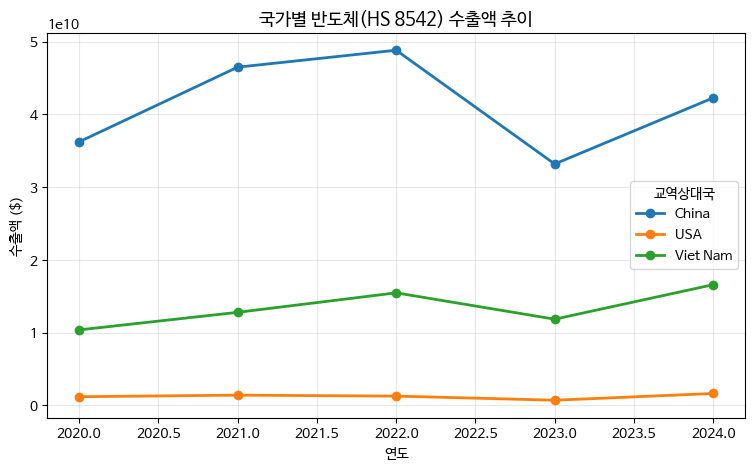

In [ ]:
plt.figure(figsize=(9, 5))
for country in semi_trend.columns:
    plt.plot(semi_trend.index, semi_trend[country],
             marker='o', linewidth=2, label=country)

plt.title('국가별 반도체(HS 8542) 수출액 추이', fontsize=13)
plt.xlabel('연도')
plt.ylabel('수출액 ($)')
plt.legend(title='교역상대국')
plt.grid(alpha=0.3)
plt.show()

### 📌 2-9. 히트맵으로 마무리
수출입을 모두 포함한 연도 × 국가 × 수출입 구조를 **히트맵**으로 종합해 봅시다.

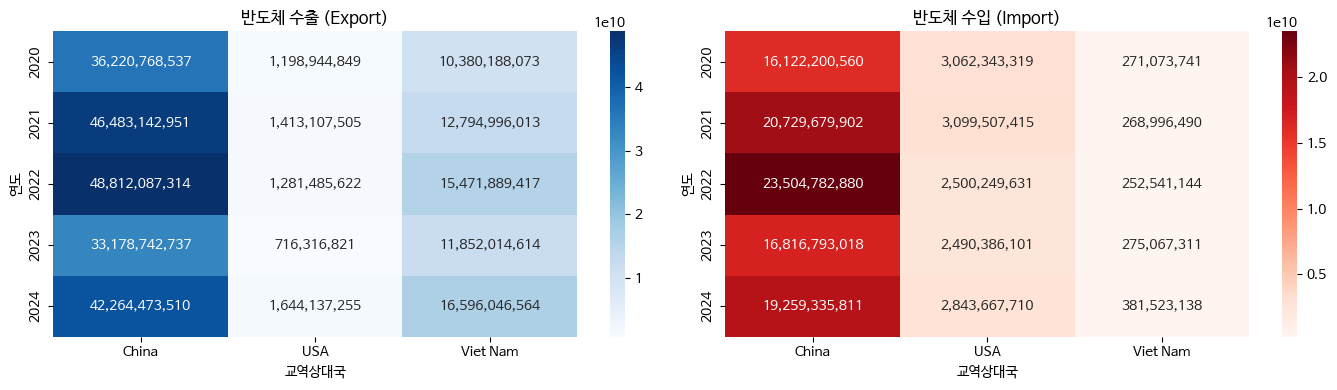

In [ ]:
heat = semi.groupby(['연도', '교역상대국', '수출입구분'])['교역금액($)'].sum().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(heat['Export'].unstack(), annot=True, fmt=',.0f',
            cmap='Blues', ax=axes[0])
axes[0].set_title('반도체 수출 (Export)')

sns.heatmap(heat['Import'].unstack(), annot=True, fmt=',.0f',
            cmap='Reds', ax=axes[1])
axes[1].set_title('반도체 수입 (Import)')

plt.tight_layout()
plt.show()

### 🎯 주제 2 결론

| 국가 | 역할 | 특징 |
|---|---|---|
| 🇨🇳 China | **양방향 교역 파트너** | 수출 최대, 수입도 최대. 분업 구조의 핵심 |
| 🇻🇳 Viet Nam | **한국 반도체의 수출 시장** | 수출이 수입의 46배. 조립·완제품 생산 기지 |
| 🇺🇸 USA | **반도체 공급자 (한국 입장)** | 수입이 수출의 2배 이상. 장비·고부가 칩 유입 |

> '반도체 = 한국의 효자 수출품'이라는 말은 절반만 맞습니다.
> **미국으로부터의 수입 의존도**, **중국이 양방향으로 연결된 구조**를 함께 이해해야 전체 그림이 보입니다.

---
---
# 🇺🇸 주제 3. 교역 무게중심이 중국에서 미국으로 이동했나?

> **배경 지식**
> - 지난 몇 년간 미·중 무역 갈등, 공급망 재편 이야기가 끊이지 않았습니다.
> - 한국의 실제 교역 구조도 그 영향을 받았을지, **2020년 vs 2024년을 비교**해서 확인합시다.

### 💡 분석 가설
- 5년 사이에 중국 비중은 감소, 미국 비중은 확대됐을 것.
- 미국 수출 확대를 이끈 품목은 자동차(HS 8703)일 것.

### 📌 3-1. 2020년과 2024년 데이터만 뽑기
`.isin()`을 써서 연도가 2020 또는 2024인 행만 필터링하세요.

In [ ]:
df_compare =
df_compare.shape

(12811, 12)

### 📌 3-2. 수출 데이터만 추리기
앞서 만든 `df_compare`에서 추가로 수출(Export)만 골라 `exp`에 저장하세요.

> 💡 복합 조건이면 한 번에 해도 되지만, 단계적으로 필터하는 것도 좋습니다.

In [ ]:
exp =
exp.shape

(6236, 12)

### 📌 3-3. 연도 × 국가 수출액 비교
연도별, 국가별 수출액 합계를 구하세요.

In [ ]:
exp_pivot =
exp_pivot

연도    교역상대국   
2020  China       132565444433
      USA          74352782505
      Viet Nam     48510572444
2024  China       132902972287
      USA         128368519881
      Viet Nam     58318358187
Name: 교역금액($), dtype: int64

In [ ]:
# (코드 실행)
exp_pivot = exp_pivot.unstack()
exp_pivot

교역상대국,China,USA,Viet Nam
연도,,,
2020,132565444433,74352782505,48510572444
2024,132902972287,128368519881,58318358187


### 📌 3-4. 증가율 계산
2020년 대비 2024년 수출이 얼마나 늘었는지 **증가율(%)** 행을 추가하세요.

In [ ]:
# (코드 실행)
exp_pivot.loc['증가율(%)'] = (exp_pivot.loc[2024] / exp_pivot.loc[2020] - 1) * 100
exp_pivot

교역상대국,China,USA,Viet Nam
연도,,,
2020,1.325654e+11,7.435278e+10,4.851057e+10
2024,1.329030e+11,1.283685e+11,5.831836e+10
증가율(%),2.546122e-01,7.264790e+01,2.021783e+01


> 🔍 **관찰**:
> - China 수출: 거의 제자리 (약 +0.3%)
> - Viet Nam 수출: 약 +20%
> - **USA 수출: 약 +73%** 🚀
> → 미국으로의 수출이 압도적으로 늘었습니다. 무게중심이 실제로 이동한 셈.

### 📌 3-5. 3개국 수출 비중 시각화
2020년과 2024년의 **수출 구성비**를 원형 그래프 2개로 비교하세요.

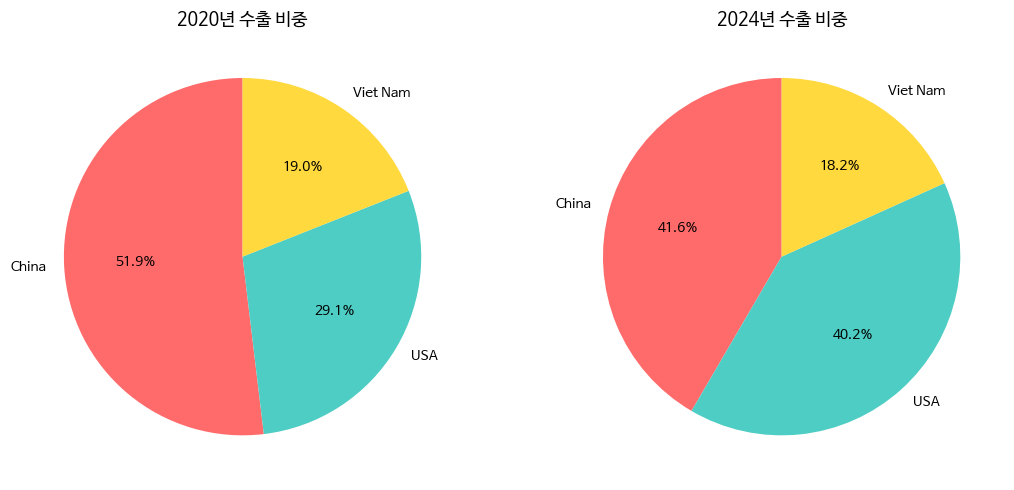

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for i, year in enumerate([2020, 2024]):
    data = exp_pivot.loc[year]
    axes[i].pie(data, labels=data.index, autopct='%1.1f%%',
                startangle=90, colors=['#FF6B6B', '#4ECDC4', '#FFD93D'])
    axes[i].set_title(f'{year}년 수출 비중', fontsize=13)

plt.tight_layout()
plt.show()

### 📌 3-6. 미국 수출 증가의 주역은?
미국의 수출 증가를 이끈 품목을 찾아봅시다.
**미국 대상 수출 + 2024년** 데이터에서 상위 5개 품목을 출력하세요.

In [ ]:
us_top = df[(df['교역상대국']=='USA') & (df['수출입구분']=='Export') & (df['연도']==2024)] \
    [['HS코드', '품목명', '교역금액($)']] \
    .sort_values('교역금액($)', ascending=False) \
    .head(5)
us_top

,HS코드,품목명,교역금액($)
28557,8703,Motor cars and other motor vehicles; principal...,35247878595
26568,8473,Machinery; parts and accessories (other than c...,8221013905
26583,8708,"Motor vehicles; parts and accessories, of head...",7070705834
28390,8523,"Discs, tapes, solid-state non-volatile storage...",5444406127
28686,2710,Petroleum oils and oils from bituminous minera...,5142924176


### 📌 3-7. 자동차(HS 8703) 수출 추이
1위 품목인 HS 8703(자동차)의 5년 추이를 확인하세요.

In [ ]:
# df에서 USA의 자동차(8703) 수출 데이터 선택
cars =
cars.shape

(5, 12)

In [ ]:
# 연도 별 교역금액 합
car_trend =
car_trend

,교역금액($)
연도,
2020,15991608654
2021,17500883947
2022,22590244982
2023,32705122291
2024,35247878595


### 📌 3-8. 시각화
자동차 수출 추이를 막대그래프로 그리고, 증가 스토리를 눈으로 확인하세요.

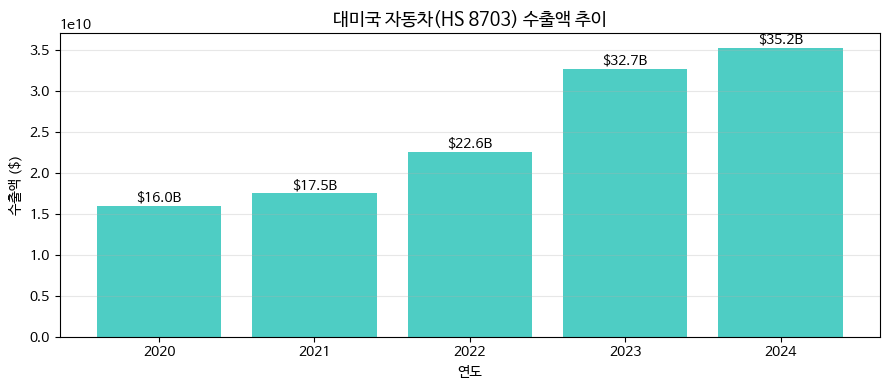

In [ ]:
plt.figure(figsize=(9, 4))
bars = plt.bar(car_trend.index, car_trend.values, color='#4ECDC4')

# 각 막대 위에 숫자 표시
for bar, val in zip(bars, car_trend.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'${val/1e9:.1f}B', ha='center', va='bottom', fontsize=10)

plt.title('대미국 자동차(HS 8703) 수출액 추이', fontsize=13)
plt.xlabel('연도')
plt.ylabel('수출액 ($)')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 🎯 주제 3 결론

| 발견 | 내용 |
|---|---|
| 3개국 수출 증가율 (2020→2024) | China +0.3% / Viet Nam +20% / **USA +73%** |
| 대미 수출 증가의 주역 | **자동차(HS 8703)** — 5년간 약 **2.2배** 증가 (160억 → 352억 달러) |
| 구조적 의미 | 중국 중심 구조가 **미국 중심으로 재편** 중. IRA·공급망 재편이 실제 무역 데이터에 반영됨 |


---
---
# 🏁 3가지 주제를 관통하는 메시지

| # | 주제 | 핵심 발견 |
|:---:|:---|:---|
| 1 | 대중국 무역수지 역전 | 2023년 적자 전환. **수입 증가가 아닌 수출 감소**(특히 반도체)가 원인 |
| 2 | 반도체 양방향 교역 | 국가별 분업 구조 확인. **중국은 양방향, 베트남은 수출, 미국은 수입** |
| 3 | 교역 무게중심 이동 | 중국 정체·미국 +73% 급증. **자동차가 대미 수출의 새로운 주역** |

### 📘 세 주제를 이어 붙이면?

**"한국 수출의 중심축이 반도체·중국에서 자동차·미국으로 빠르게 이동 중이다."**

- 전통적 효자였던 **반도체의 대중국 수출이 꺾이면서** 무역수지가 적자로 돌아섰고
- 그 공백을 **자동차의 대미국 수출**이 메우고 있다는 그림이 이 데이터 한 묶음에서 드러납니다.

---

### 💡 이 실습에서 자연스럽게 연습한 판다스 기능

- `pd.read_excel`, `.shape`, `.head`, `.describe`, `.unique`
- 불리언 인덱싱 (`df[df['A']==x]`), `&`, `.isin()`, `.str.contains()`
- `.groupby().sum()`, `.unstack()`, `.sort_values()`
- 새 컬럼 생성 (`df['새컬럼'] = ...`)
- `.str` 접근자 (`.astype(str).str.zfill(4).str[:2]`)
- matplotlib 선/막대/파이, seaborn 히트맵

> 함수 하나하나를 따로 외우기보다, **질문에 답하기 위해 어떻게 조합하는지**를 익히는 것이 실전 EDA입니다.

수고하셨습니다! 🎉
